<a href="https://colab.research.google.com/github/Hope-Alemayehu/causal-inference-medical-treatment/blob/main/bayesian_network_medical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Network — Medical Treatment
## Fork, Chain, and Collider Structures

An interactive Bayesian network demonstrating how beliefs update
in real time as clinical evidence arrives.

## What This Notebook Shows

- **Fork structure** — Severity as confounder affecting both
  Treatment and Recovery
- **Chain structure** — Age → Severity → Treatment → Recovery
- **Collider structure** — Discharged as a common effect of
  Treatment and Recovery

## Key Demonstration

Explaining away: conditioning on the collider (Discharged)
changes how Treatment and Recovery relate to each other —
even though they have no direct connection in the real world.

## Why This Matters in Medical AI

Hospital studies often condition on discharged patients because
that's who has complete records. This is Berkson's paradox —
conditioning on a collider creates spurious correlations that
don't exist in the real population.

## Connection to Pearl's Ladder

| This notebook | Pearl's Rung |
|---|---|
| Bayesian belief updating | Rung 1 — Association |
| DoWhy causal model (prev notebook) | Rung 2 — Intervention |
| Counterfactual reasoning | Rung 3 — not built yet |

## Tools
- `pgmpy` — Probabilistic graphical models
- `networkx` — Graph visualization
- `matplotlib` — Plotting

In [ ]:
pip install pgmpy

In [5]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
# Define the structure
model = DiscreteBayesianNetwork([
    ('Age', 'Severity'),
    ('Age', 'Recovery'),
    ('Severity', 'Treatment'),
    ('Severity', 'Recovery'),
    ('Treatment', 'Recovery'),
    ('Treatment', 'Discharged'),
    ('Recovery', 'Discharged')
])

print("Network structure defined.")
print("Nodes:", model.nodes())
print("Edges:", model.edges())

Network structure defined.
Nodes: ['Age', 'Severity', 'Recovery', 'Treatment', 'Discharged']
Edges: [('Age', 'Severity'), ('Age', 'Recovery'), ('Severity', 'Treatment'), ('Severity', 'Recovery'), ('Recovery', 'Discharged'), ('Treatment', 'Recovery'), ('Treatment', 'Discharged')]


In [7]:
# AGE: no parents — just a prior probability
# 0 = Young, 1 = Old
cpd_age = TabularCPD(
    variable='Age',
    variable_card=2,
    values=[[0.4],   # P(Young)
            [0.6]]   # P(Old)
)

# SEVERITY: caused by Age
# 0 = Mild, 1 = Severe
# Columns: Young, Old
cpd_severity = TabularCPD(
    variable='Severity',
    variable_card=2,
    values=[[0.7, 0.3],   # P(Mild | Young), P(Mild | Old)
            [0.3, 0.7]],  # P(Severe | Young), P(Severe | Old)
    evidence=['Age'],
    evidence_card=[2]
)

# TREATMENT: caused by Severity
# 0 = No Treatment, 1 = Treatment
# Columns: Mild, Severe
cpd_treatment = TabularCPD(
    variable='Treatment',
    variable_card=2,
    values=[[0.2, 0.7],   # P(No Treatment | Mild), P(No Treatment | Severe)
            [0.8, 0.3]],  # P(Treatment | Mild), P(Treatment | Severe)
    evidence=['Severity'],
    evidence_card=[2]
)

print("First three CPDs defined.")

First three CPDs defined.


In [8]:
# RECOVERY: caused by Age, Severity, Treatment
# 0 = No Recovery, 1 = Recovery
# 8 columns = all combinations of parents
cpd_recovery = TabularCPD(
    variable='Recovery',
    variable_card=2,
    values=[
        # Young-Mild-NoTx, Young-Mild-Tx, Young-Sev-NoTx, Young-Sev-Tx,
        # Old-Mild-NoTx,   Old-Mild-Tx,   Old-Sev-NoTx,   Old-Sev-Tx
        [0.2, 0.1, 0.5, 0.3, 0.3, 0.2, 0.7, 0.5],  # P(No Recovery)
        [0.8, 0.9, 0.5, 0.7, 0.7, 0.8, 0.3, 0.5]   # P(Recovery)
    ],
    evidence=['Age', 'Severity', 'Treatment'],
    evidence_card=[2, 2, 2]
)

# DISCHARGED: caused by Treatment and Recovery
# 0 = Not Discharged, 1 = Discharged
# Columns: NoTx-NoRec, NoTx-Rec, Tx-NoRec, Tx-Rec
cpd_discharged = TabularCPD(
    variable='Discharged',
    variable_card=2,
    values=[
        [0.8, 0.2, 0.5, 0.1],  # P(Not Discharged)
        [0.2, 0.8, 0.5, 0.9]   # P(Discharged)
    ],
    evidence=['Treatment', 'Recovery'],
    evidence_card=[2, 2]
)

print("All CPDs defined.")

All CPDs defined.


In [9]:
# Add all CPDs to the model
model.add_cpds(
    cpd_age,
    cpd_severity,
    cpd_treatment,
    cpd_recovery,
    cpd_discharged
)

# Validate — checks two things:
# 1. All probabilities sum to 1
# 2. CPD structure matches network structure
print("Model valid:", model.check_model())

Model valid: True


In [10]:
# Set up inference engine
inference = VariableElimination(model)

print("=" * 50)
print("BASELINE — No evidence")
print("=" * 50)

# Query Recovery with no evidence
q1 = inference.query(['Recovery'])
print(q1)

print("\n" + "=" * 50)
print("EVIDENCE: Patient is Old")
print("=" * 50)

q2 = inference.query(['Recovery'],
                      evidence={'Age': 1})
print(q2)

print("\n" + "=" * 50)
print("EVIDENCE: Patient is Old AND Severe")
print("=" * 50)

q3 = inference.query(['Recovery'],
                      evidence={'Age': 1,
                                'Severity': 1})
print(q3)

BASELINE — No evidence
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.3948 |
+-------------+-----------------+
| Recovery(1) |          0.6052 |
+-------------+-----------------+

EVIDENCE: Patient is Old
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.5140 |
+-------------+-----------------+
| Recovery(1) |          0.4860 |
+-------------+-----------------+

EVIDENCE: Patient is Old AND Severe
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.6400 |
+-------------+-----------------+
| Recovery(1) |          0.3600 |
+-------------+-----------------+


In [11]:
print("=" * 50)
print("EXPLAINING AWAY DEMONSTRATION")
print("=" * 50)

print("\nQ1: P(Recovery | Discharged)")
q4 = inference.query(['Recovery'],
                      evidence={'Discharged': 1})
print(q4)

print("\nQ2: P(Recovery | Discharged, No Treatment)")
q5 = inference.query(['Recovery'],
                      evidence={'Discharged': 1,
                                'Treatment': 0})
print(q5)

print("\nQ3: P(Recovery | Discharged, Treatment)")
q6 = inference.query(['Recovery'],
                      evidence={'Discharged': 1,
                                'Treatment': 1})
print(q6)

EXPLAINING AWAY DEMONSTRATION

Q1: P(Recovery | Discharged)
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.1817 |
+-------------+-----------------+
| Recovery(1) |          0.8183 |
+-------------+-----------------+

Q2: P(Recovery | Discharged, No Treatment)
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.2520 |
+-------------+-----------------+
| Recovery(1) |          0.7480 |
+-------------+-----------------+

Q3: P(Recovery | Discharged, Treatment)
+-------------+-----------------+
| Recovery    |   phi(Recovery) |
+=============+=================+
| Recovery(0) |          0.1464 |
+-------------+-----------------+
| Recovery(1) |          0.8536 |
+-------------+-----------------+


In [13]:
print("=" * 50)
print("FULL NETWORK BELIEF UPDATE")
print("=" * 50)

def print_beliefs(title, evidence={}):
    print(f"\n{title}")
    for var in ['Severity', 'Treatment', 'Recovery', 'Discharged']:
        if var in evidence:
            # Already observed — just print what we know
            print(f"  P({var}=1): OBSERVED = {evidence[var]}")
        else:
            q = inference.query([var], evidence=evidence)
            val = q.values[1]
            print(f"  P({var}=1): {val:.3f}")

print_beliefs("BASELINE — No evidence:", {})

print_beliefs("Old patient, Severe:",
              {'Age': 1, 'Severity': 1})

print_beliefs("Old, Severe, AND Treated:",
              {'Age': 1, 'Severity': 1, 'Treatment': 1})

print_beliefs("Old, Severe, Treated, AND Recovered:",
              {'Age': 1, 'Severity': 1,
               'Treatment': 1, 'Recovery': 1})

FULL NETWORK BELIEF UPDATE

BASELINE — No evidence:
  P(Severity=1): 0.540
  P(Treatment=1): 0.530
  P(Recovery=1): 0.605
  P(Discharged=1): 0.641

Old patient, Severe:
  P(Severity=1): OBSERVED = 1
  P(Treatment=1): 0.300
  P(Recovery=1): 0.360
  P(Discharged=1): 0.476

Old, Severe, AND Treated:
  P(Severity=1): OBSERVED = 1
  P(Treatment=1): OBSERVED = 1
  P(Recovery=1): 0.500
  P(Discharged=1): 0.700

Old, Severe, Treated, AND Recovered:
  P(Severity=1): OBSERVED = 1
  P(Treatment=1): OBSERVED = 1
  P(Recovery=1): OBSERVED = 1
  P(Discharged=1): 0.900


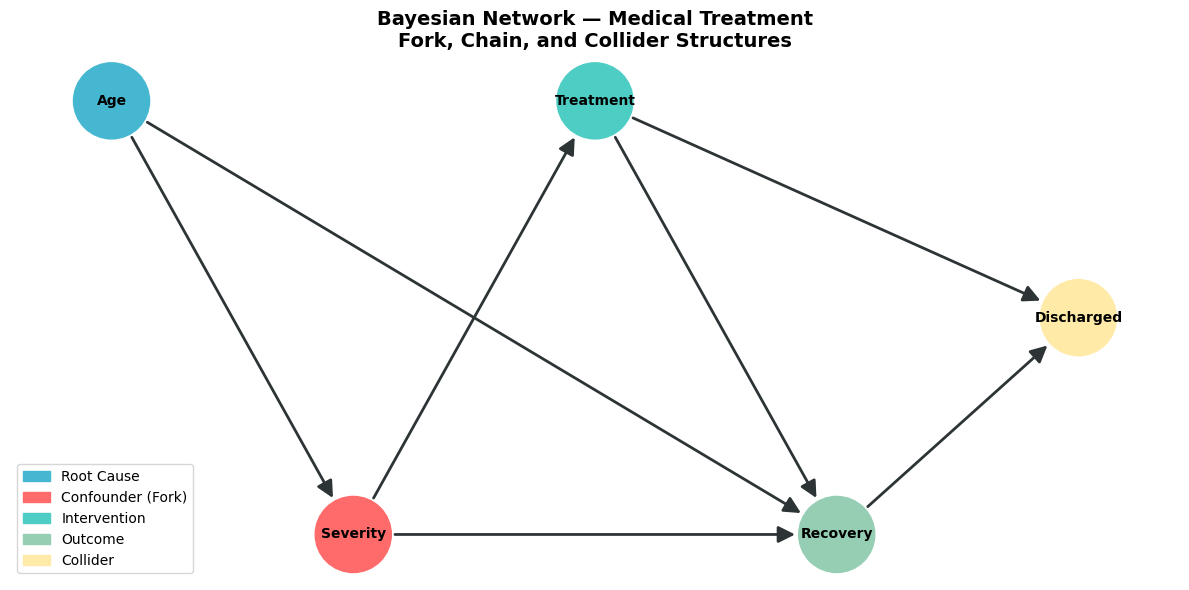

Network visualization saved.


In [15]:
# Build the directed graph
G = nx.DiGraph()
G.add_edges_from([
    ('Age', 'Severity'),
    ('Age', 'Recovery'),
    ('Severity', 'Treatment'),
    ('Severity', 'Recovery'),
    ('Treatment', 'Recovery'),
    ('Treatment', 'Discharged'),
    ('Recovery', 'Discharged')
])

# Color nodes by type
colors = {
    'Age':       '#45b7d1',  # blue  — root cause
    'Severity':  '#ff6b6b',  # red   — confounder
    'Treatment': '#4ecdc4',  # teal  — intervention
    'Recovery':  '#96ceb4',  # green — outcome
    'Discharged':'#ffeaa7',  # yellow — collider
}

node_colors = [colors[n] for n in G.nodes()]

# Layout
pos = {
    'Age':       (0, 2),
    'Severity':  (1, 1),
    'Treatment': (2, 2),
    'Recovery':  (3, 1),
    'Discharged':(4, 1.5)
}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

nx.draw_networkx_nodes(G, pos,
                        node_color=node_colors,
                        node_size=3000, ax=ax)

nx.draw_networkx_labels(G, pos,
                         font_size=10,
                         font_weight='bold', ax=ax)

nx.draw_networkx_edges(G, pos,
                        edge_color='#2d3436',
                        arrows=True,
                        arrowsize=25,
                        arrowstyle='-|>',
                        width=2,
                        min_source_margin=30,
                        min_target_margin=30,
                        ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#45b7d1', label='Root Cause'),
    mpatches.Patch(color='#ff6b6b', label='Confounder (Fork)'),
    mpatches.Patch(color='#4ecdc4', label='Intervention'),
    mpatches.Patch(color='#96ceb4', label='Outcome'),
    mpatches.Patch(color='#ffeaa7', label='Collider'),
]
ax.legend(handles=legend_elements,
          loc='lower left', fontsize=10)

ax.set_title('Bayesian Network — Medical Treatment\n'
             'Fork, Chain, and Collider Structures',
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('bayesian_network.png', dpi=150, bbox_inches='tight')
plt.show()

print("Network visualization saved.")